# The Mandelbrot set

The Mandelbrot set is defined as the set of complex numbers $c$ for which the iterative sequence: 
$z_{n+1} = z_n^2 + c$

with $z_0 = 0$, remains bounded (doesn't diverge to infinity) which we define as, $|z_{n+1}| \leq 2$ for all $n$.

So the first interations of the sequence looks like this.
$z_0 = 0$   
$z_1 = 0 + c = c$   
$z_2 = c² + c$  
$z_3 = (c²+c)² + c$     
...

## The naive approach in Python
When calculating all the values in the Mandelbrot set, one could take a naive approach. Disregarding any optimization choices and use default python lists and nested for loops:

In [1]:
# Define the limits and parameters for the mandelbrot set.
# The typical view (limits) as defined by the problem description from moodle.
x_min = -2.0 
x_max =  1.0
y_min = -1.5
y_max =  1.5

# Minimum resolution to start with. Will be updated later to test scalability.
width = 1024
height = 1024

# Fixed number of iterations taken from moodle.
max_iterations = 100


def mandelbrot(c, max_iterations):
    z = 0
    n = 0

    # Keep interating as long as the magnitude of z is less than or equal to 2 (doesn't diverge to infinity) and we haven't reached the maximum number of iterations.
    while abs(z) <= 2.0 and n < max_iterations:
        z = z*z + c
        n += 1
    return n


def generate_mandelbrot_set_naive():

    # Create a naive 2D list to hold the values.
    mandelbrot_set = [[0 for _ in range(width)] for _ in range(height)]

    # Loop through all pixels and determine how many iterations it takes for the corresponding magnitude to become greater than 2 (indicating divergence to infinity).
    for y in range(height):
        for x in range(width):
            real = x_min + (x / width) * (x_max - x_min)
            imag = y_min + (y / height) * (y_max - y_min)
            c = complex(real, imag)
            mandelbrot_set[y][x] = mandelbrot(c, max_iterations)

    # Return interation counts for each complex number.
    return mandelbrot_set

mandelbrot_set_naive = generate_mandelbrot_set_naive()
naive_result = %timeit -o generate_mandelbrot_set_naive()


2.54 s ± 119 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


As we can see the naive approach results in each function call taking multiple seconds to complete at this scale (1024 x 1024).

Using a colorbar plot we can visualize the set and confirm that we get the expected result:

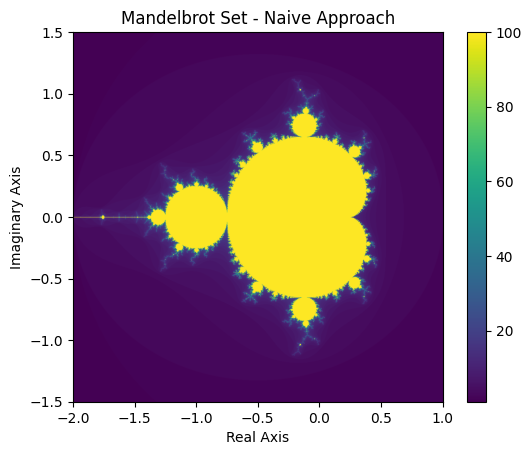

In [2]:
import matplotlib.pyplot as plt

# Plotting the set using colorbar.
plt.imshow(mandelbrot_set_naive, extent=(x_min, x_max, y_min, y_max))
plt.colorbar()
plt.title("Mandelbrot Set - Naive Approach")
plt.xlabel("Real Axis")
plt.ylabel("Imaginary Axis")
plt.show()

## Vectorized approach in Python using NumPy
Now that we have tried the naive approach we can start thinking about ways to optimize the approach. - and as listed by the problem description the first option that we try to implement is a vectorized approach.

In the vectorized approach we try to limit the amount of loops by replacing the (looped) interations with calculations that can be done simultaneously with vector operations:

In [3]:
import numpy as np

def generate_mandelbrot_set_vectorized():

    # Create a 2D array of complex numbers representing the points in the complex plane.
    real = np.linspace(x_min, x_max, width)
    imag = np.linspace(y_min, y_max, height)

    # Define all the complex numbers in the grid.
    c = np.array([[complex(r, i) for r in real] for i in imag])

    # Initialize an array to hold the number of iterations for each point.
    mandelbrot_set = np.zeros(c.shape, dtype=int)

    # Create an array to hold the current values of z for each point.
    z = np.zeros(c.shape, dtype=complex)

    # Iterate up to max_iterations times, updating all points simultaneously using vectorized operations.
    for n in range(max_iterations):
        mask = np.abs(z) <= 2.0  # Only update points that haven't diverged (magnitude <= 2).
        z[mask] = z[mask] * z[mask] + c[mask]  # Update z for those points.
        mandelbrot_set[mask] = n  # Update the iteration count for those points.

    # Return interation counts for each complex number.
    return mandelbrot_set

mandelbrot_set_vectorized = generate_mandelbrot_set_vectorized()
vectorized_result = %timeit -o generate_mandelbrot_set_vectorized()

880 ms ± 18.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


And now we see that a function call takes just shy of 1 second to complete at the same scale (1024 x 1024).

Again, we can use a colorbar plot we can visualize the set and confirm that we get the expected result:

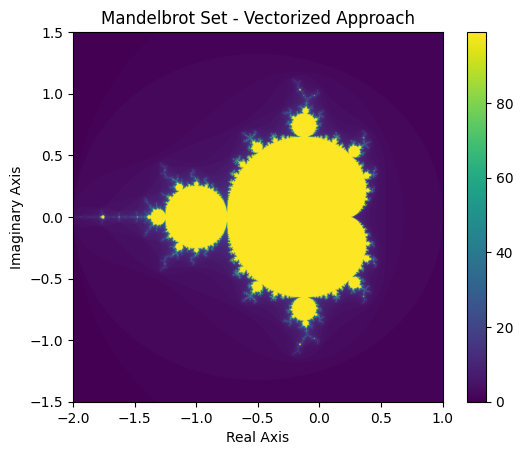

In [4]:
# Plotting the new set using colorbar.
plt.imshow(mandelbrot_set_vectorized, extent=(x_min, x_max, y_min, y_max))
plt.colorbar()
plt.title("Mandelbrot Set - Vectorized Approach")
plt.xlabel("Real Axis")
plt.ylabel("Imaginary Axis")
plt.show()

## Precompiled approach using Numba and JIT (Just In Time compilation)
Now that we have tried to optimize the approach using vector calculations, we can also try to just let the compiler optimize for us using JIT. -Specifically numba.jit():

In [5]:
import numba

@numba.jit(nopython=True)
def generate_mandelbrot_set_jit():


    # Define helper function here to avoid numba issues with nested functions.
    def mandelbrot(c, max_iterations):
        z = 0
        n = 0

        # Keep interating as long as the magnitude of z is less than or equal to 2 (doesn't diverge to infinity) and we haven't reached the maximum number of iterations.
        while abs(z) <= 2.0 and n < max_iterations:
            z = z*z + c
            n += 1
        return n

    # Create a naive 2D list to hold the values.
    mandelbrot_set = [[0 for _ in range(width)] for _ in range(height)]

    # Loop through all pixels and determine how many iterations it takes for the corresponding magnitude to become greater than 2 (indicating divergence to infinity).
    for y in range(height):
        for x in range(width):
            real = x_min + (x / width) * (x_max - x_min)
            imag = y_min + (y / height) * (y_max - y_min)
            c = complex(real, imag)
            mandelbrot_set[y][x] = mandelbrot(c, max_iterations)

    # Return interation counts for each complex number.
    return mandelbrot_set

mandelbrot_set_jit = generate_mandelbrot_set_jit()
jit_result = %timeit -o generate_mandelbrot_set_jit()

211 ms ± 4.46 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


And here se see even more improvement compared to the naive approach. -eventhough we just compiled it.

Again, we can use a colorbar plot we can visualize the set and confirm that we get the expected result:

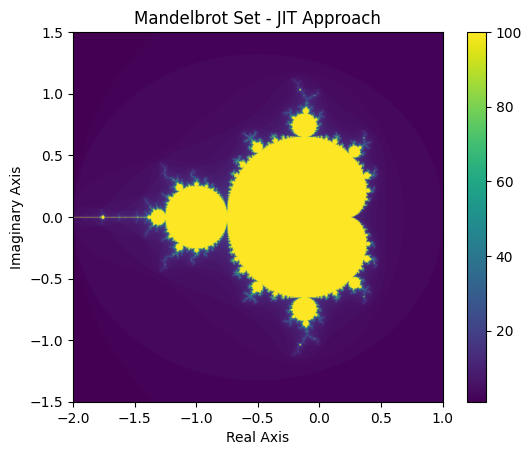

In [6]:
# Plotting the JIT set using colorbar.
plt.imshow(mandelbrot_set_jit, extent=(x_min, x_max, y_min, y_max))
plt.colorbar()
plt.title("Mandelbrot Set - JIT Approach")
plt.xlabel("Real Axis")
plt.ylabel("Imaginary Axis")
plt.show()

## Performance analysis

Now that we have implemented all three approaches and measured the time it takes for each, we can compare them:

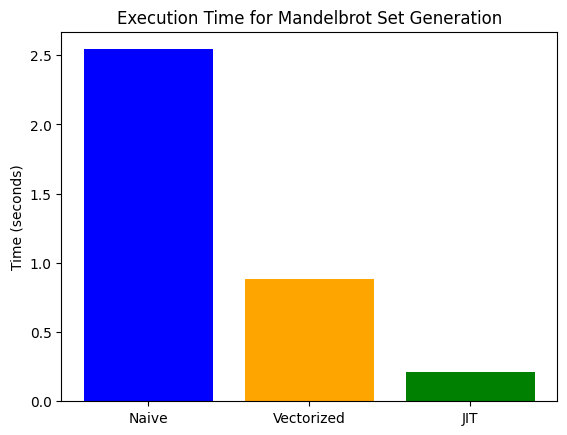

In [7]:
# Plot the time results for the three approaches.
approaches = ['Naive', 'Vectorized', 'JIT']
times = [naive_result.average, vectorized_result.average, jit_result.average]
plt.bar(approaches, times, color=['blue', 'orange', 'green'])
plt.ylabel('Time (seconds)')
plt.title('Execution Time for Mandelbrot Set Generation')
plt.show()

The problem description from moodle also states that we should calculate the speedups which have been presented as: $S_p = T_1 / T_p$. - but since none of the implementation has been done using parallel computing i will adjust the meaning of the variables

$T_1:$ naive time,  $T_p:$ vectorized or JIT time


In [8]:
speedup_vectorized = naive_result.average / vectorized_result.average
speedup_jit = naive_result.average / jit_result.average

print(f"Speedup of Vectorized approach over Naive: {speedup_vectorized:.2f}x")
print(f"Speedup of JIT approach over Naive: {speedup_jit:.2f}x")

Speedup of Vectorized approach over Naive: 2.89x
Speedup of JIT approach over Naive: 12.08x


The difference in performance from naive to vectorized comes from:
1. Uptimized instructions for vectors vs for loops: The instruction set that a processors have can be better optimized for vector calculations than for loops.
2. Cache misses: Since are using the native python list in the naive approach, our memory layout of the lists might be non-contiguous (strided) or contiguous (unit stride).

The difference in performance from vectorized to JIT comes from:
1. Compiler optimizations: Beyond the optimization from using vectors, there might be unknown optimizations that can be access when using a compiler.

## Scaling analysis



In [9]:
# Create list of scales
scales = [1024, 1536, 2048, 3072, 4096]

# Run the three approaches for each scale and store the results.
naive_results = []
vectorized_results = []
jit_results = []
for scale in scales:
    width = height = scale  # Update the resolution for the current scale.

    # Run and store results for each approach.
    naive_result = %timeit -o generate_mandelbrot_set_naive()
    naive_results.append(naive_result)

2.55 s ± 47.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
5.67 s ± 118 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
9.97 s ± 55.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
22.2 s ± 203 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
39.3 s ± 87.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [10]:
for scale in scales:
    width = height = scale  # Update the resolution for the current scale.

    # Run and store results for each approach.
    vectorized_result = %timeit -o generate_mandelbrot_set_vectorized()
    vectorized_results.append(vectorized_result)

864 ms ± 8.44 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.27 s ± 22.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
4.46 s ± 17.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
12.4 s ± 47.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
23.9 s ± 222 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [11]:
for scale in scales:
    width = height = scale  # Update the resolution for the current scale.

    # Run and store results for each approach.
    jit_result = %timeit -o generate_mandelbrot_set_jit()
    jit_results.append(jit_result)


208 ms ± 3.49 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
212 ms ± 13.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
207 ms ± 1.65 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
206 ms ± 945 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
206 ms ± 739 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [12]:
print("Scalability results:")
print("Naive approach:")
for i, scale in enumerate(scales):
    print(f"Scale {scale}x{scale}: {naive_results[i].average:.4f} seconds")
print("\nVectorized approach:")
for i, scale in enumerate(scales):
    print(f"Scale {scale}x{scale}: {vectorized_results[i].average:.4f} seconds")
print("\nJIT approach:")
for i, scale in enumerate(scales):
    print(f"Scale {scale}x{scale}: {jit_results[i].average:.4f} seconds")

Scalability results:
Naive approach:
Scale 1024x1024: 2.5495 seconds
Scale 1536x1536: 5.6721 seconds
Scale 2048x2048: 9.9655 seconds
Scale 3072x3072: 22.1901 seconds
Scale 4096x4096: 39.3324 seconds

Vectorized approach:
Scale 1024x1024: 0.8641 seconds
Scale 1536x1536: 2.2658 seconds
Scale 2048x2048: 4.4591 seconds
Scale 3072x3072: 12.4479 seconds
Scale 4096x4096: 23.8635 seconds

JIT approach:
Scale 1024x1024: 0.2081 seconds
Scale 1536x1536: 0.2117 seconds
Scale 2048x2048: 0.2072 seconds
Scale 3072x3072: 0.2065 seconds
Scale 4096x4096: 0.2062 seconds


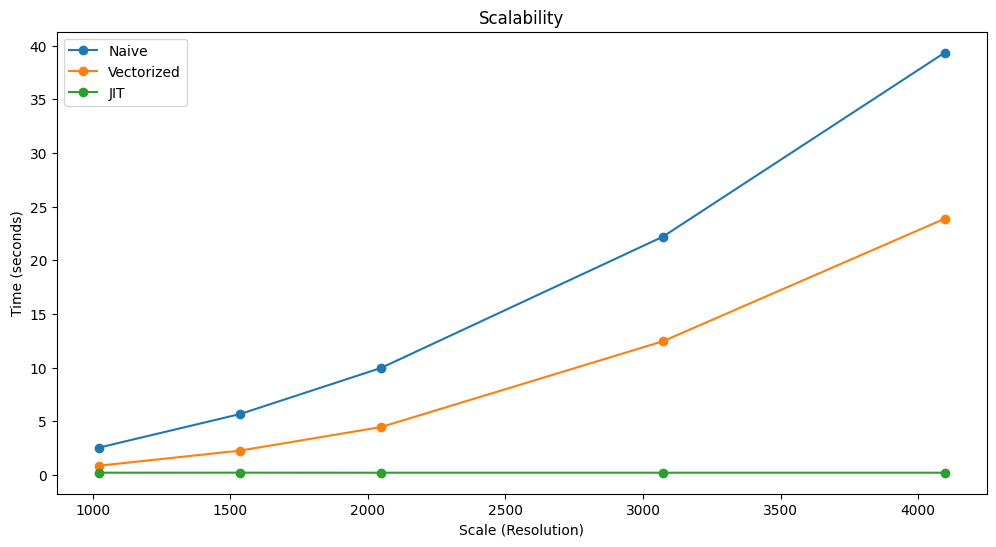

In [13]:
# Plotting the scalability results for each approach.
plt.figure(figsize=(12, 6))
plt.plot(scales, [result.average for result in naive_results], label='Naive', marker='o')
plt.plot(scales, [result.average for result in vectorized_results], label='Vectorized', marker='o')
plt.plot(scales, [result.average for result in jit_results], label='JIT', marker='o')
plt.xlabel('Scale (Resolution)')
plt.ylabel('Time (seconds)')
plt.title('Scalability')
plt.legend()
plt.show()

In [14]:
# Export results to CSV as requested in the problem description.
import csv

with open('mandelbrot_scalability_results.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Scale', 'Naive Time (s)', 'Vectorized Time (s)', 'JIT Time (s)'])
    for i, scale in enumerate(scales):
        writer.writerow([f"{scale}x{scale}", f"{naive_results[i].average:.4f}", f"{vectorized_results[i].average:.4f}", f"{jit_results[i].average:.4f}"])